# 01 — Data Exploration

First step before touching any model — just look at the data.
Figure out what's in each table, what's missing, and what patterns stand out.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# walks up from cwd until it finds the folder with src/ and requirements.txt
def find_project_root(start: Path, depth: int = 5) -> Path:
    path = start.resolve()
    for _ in range(depth):
        if (path / "src").exists() and (path / "requirements.txt").exists():
            return path
        path = path.parent
    raise RuntimeError(f"Can't find project root from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loader import load_raw_tables, build_master_df, add_parsed_lap_times

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)
print("Root:", PROJECT_ROOT)

Root: C:\Users\Agam Katiyar\Projects\f1-ml-predictions


## Raw tables overview

In [2]:
tables = load_raw_tables()

for name, df in tables.items():
    print(f"{name:30s}  {df.shape}")

races                           (1125, 18)
results                         (26759, 18)
qualifying                      (10494, 9)
drivers                         (861, 9)
constructors                    (212, 5)
driver_standings                (34863, 7)
constructor_standings           (13391, 7)
circuits                        (77, 9)
status                          (139, 2)


## results.csv — the target table

One row per driver per race. `positionOrder` is what we'll predict.

In [3]:
results = tables["results"]
print(results.dtypes)
print()
results.head(10)

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number             float64
grid                 int64
position           float64
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds       float64
fastestLap         float64
rank               float64
fastestLapTime      object
fastestLapSpeed    float64
statusId             int64
dtype: object



,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1
5,6,18,6,3,8.0,13,6.0,6,6,3.0,57,NaN,NaN,50.0,14.0,1:29.639,212.974,11
6,7,18,7,5,14.0,17,7.0,7,7,2.0,55,NaN,NaN,54.0,8.0,1:29.534,213.224,5
7,8,18,8,6,1.0,15,8.0,8,8,1.0,53,NaN,NaN,20.0,4.0,1:27.903,217.180,5
8,9,18,9,2,4.0,2,NaN,R,9,0.0,47,NaN,NaN,15.0,9.0,1:28.753,215.100,4
9,10,18,10,7,12.0,18,NaN,R,10,0.0,43,NaN,NaN,23.0,13.0,1:29.558,213.166,3


In [4]:
# check what's actually missing
missing = results.isnull().sum()
print(missing[missing > 0])

number                 6
position           10953
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
dtype: int64


## Grid position vs podium

Starting from pole is a massive advantage — let's see how big.

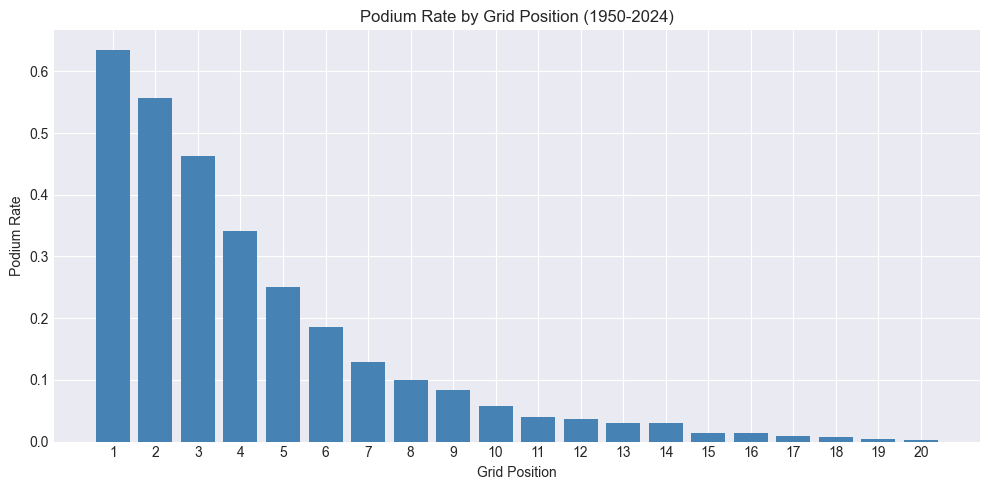

In [5]:
df = build_master_df(tables)
df = add_parsed_lap_times(df)

df["is_podium"]     = (df["positionOrder"] <= 3).astype(int)
df["grid"]          = pd.to_numeric(df["grid"], errors="coerce")
df["grid_position"] = df["grid"].replace(0, 20)  # pit lane start -> treat as last

podium_by_grid = (
    df[df["grid_position"].between(1, 20)]
    .groupby("grid_position")["is_podium"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(podium_by_grid["grid_position"], podium_by_grid["is_podium"], color="steelblue")
ax.set_xlabel("Grid Position")
ax.set_ylabel("Podium Rate")
ax.set_title("Podium Rate by Grid Position (1950-2024)")
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "podium_rate_by_grid.png", dpi=150)
plt.show()

## Class balance

Only ~13% of entries are podiums (3 out of ~20 cars). This imbalance means we can't just use raw accuracy as a metric.

is_podium
No Podium    0.873052
Podium       0.126948
Name: proportion, dtype: float64


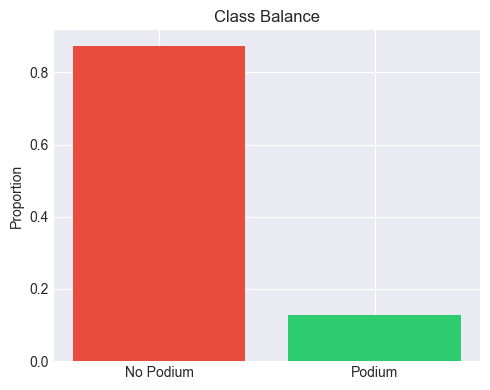

In [6]:
balance = df["is_podium"].value_counts(normalize=True)
print(balance.rename({0: "No Podium", 1: "Podium"}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No Podium", "Podium"], balance.values, color=["#e74c3c", "#2ecc71"])
ax.set_ylabel("Proportion")
ax.set_title("Class Balance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=150)
plt.show()

## Qualifying data availability

Q1/Q2/Q3 format started in 2006. Anything before that has no qualifying times.

In [7]:
for col in ["q1_seconds", "q2_seconds", "q3_seconds"]:
    if col in df.columns:
        pct = df[col].isna().mean()
        print(f"{col}: {pct:.1%} missing")

q1_seconds: 61.4% missing
q2_seconds: 78.1% missing
q3_seconds: 86.4% missing


## Constructor dominance

The car matters as much as the driver in F1.

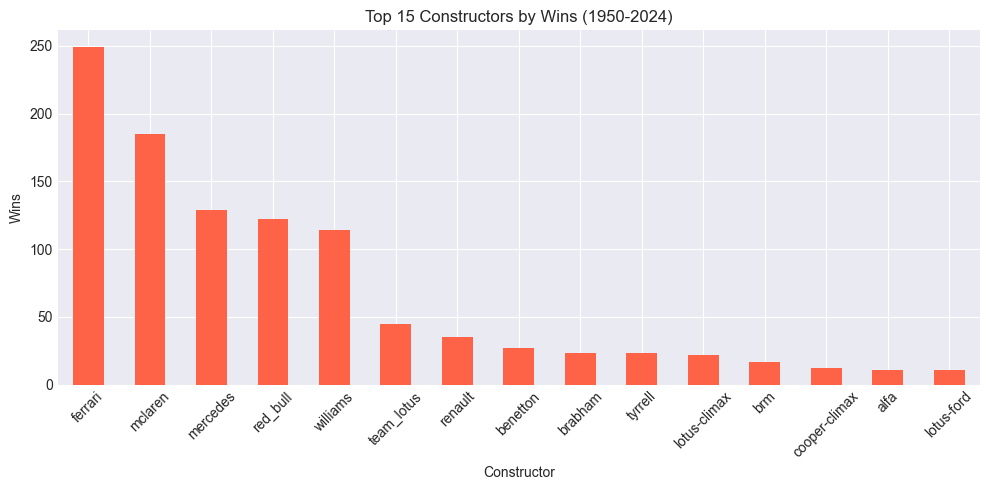

In [8]:
constructor_wins = (
    df[df["positionOrder"] == 1]
    .groupby("constructorRef")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
constructor_wins.plot(kind="bar", ax=ax, color="tomato")
ax.set_xlabel("Constructor")
ax.set_ylabel("Wins")
ax.set_title("Top 15 Constructors by Wins (1950-2024)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "constructor_wins.png", dpi=150)
plt.show()

## Races per season

Grew from 7 in 1950 to 24 recently — relevant for rolling features.

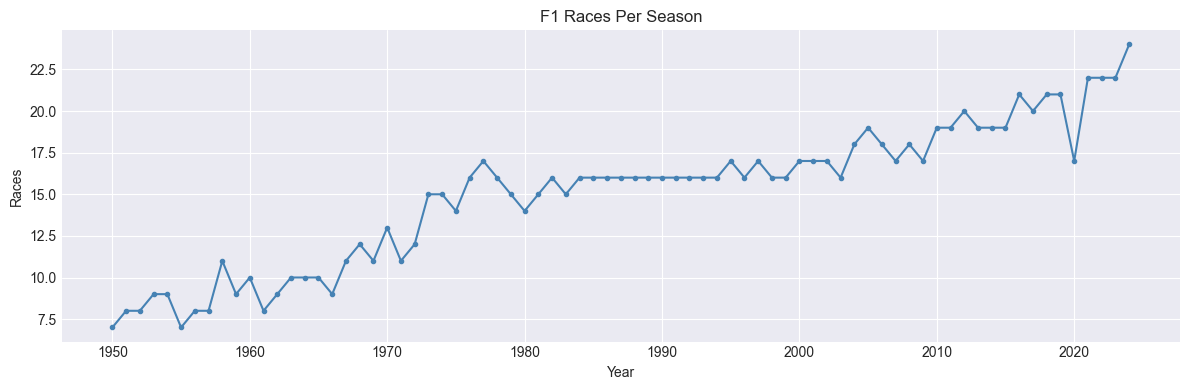

done — figures at: C:\Users\Agam Katiyar\Projects\f1-ml-predictions\outputs\figures


In [9]:
races_per_year = df.groupby("year")["raceId"].nunique()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(races_per_year.index, races_per_year.values,
        marker="o", markersize=3, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Races")
ax.set_title("F1 Races Per Season")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "races_per_year.png", dpi=150)
plt.show()

print("done — figures at:", FIGURES_DIR)